In [1]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
import os

os.listdir()

['.config', 'Sample - Superstore.csv', 'sample_data']

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9994
Columns: 21


In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [9]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [11]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [14]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [18]:
df = df.drop_duplicates()

In [20]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%B')

In [21]:
print("Years in dataset:", sorted(df['Year'].unique()))

Years in dataset: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]


In [22]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02


In [23]:
region_performance = df.groupby('Region')[['Sales', 'Profit']].sum()

print(region_performance)

               Sales       Profit
Region                           
Central  501239.8908   39706.3625
East     678781.2400   91522.7800
South    391721.9050   46749.4303
West     725457.8245  108418.4489


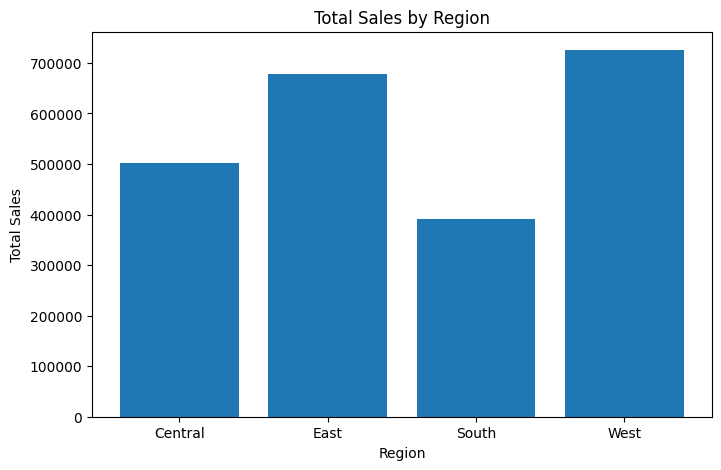

In [24]:
plt.figure(figsize=(8,5))

region_sales = df.groupby('Region')['Sales'].sum()

bars = plt.bar(region_sales.index, region_sales.values)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

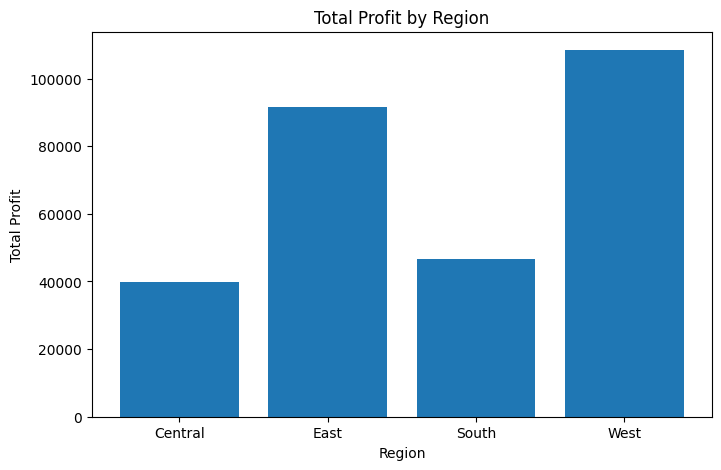

In [25]:
plt.figure(figsize=(8,5))

region_profit = df.groupby('Region')['Profit'].sum()

bars = plt.bar(region_profit.index, region_profit.values)

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.show()

In [26]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


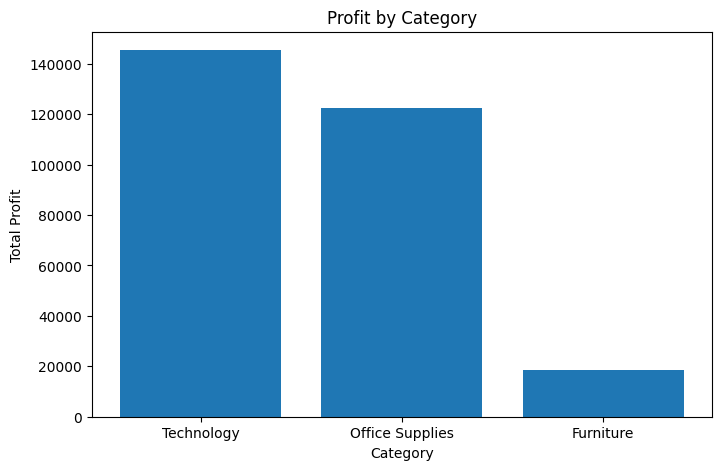

In [27]:
plt.figure(figsize=(8,5))

plt.bar(category_profit.index, category_profit.values)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

In [28]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

print(subcategory_profit)

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


In [29]:
loss_subcategories = subcategory_profit[subcategory_profit < 0]

print("Loss-making sub-categories:")
print(loss_subcategories)

Loss-making sub-categories:
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64


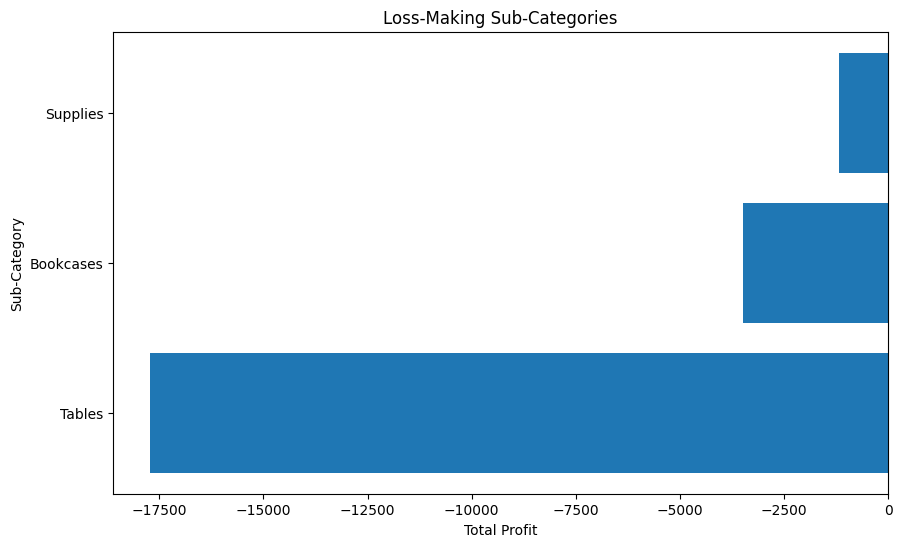

In [30]:
plt.figure(figsize=(10,6))

plt.barh(
    loss_subcategories.index,
    loss_subcategories.values
)

plt.title("Loss-Making Sub-Categories")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.show()

In [31]:
discount_profit = df.groupby('Discount')['Profit'].agg(['sum', 'mean'])

print(discount_profit)

                  sum        mean
Discount                         
0.00      320987.6032   66.900292
0.10        9029.1770   96.055074
0.15        1418.9915   27.288298
0.20       90337.3060   24.702572
0.30      -10369.2774  -45.679636
0.32       -2391.1377  -88.560656
0.40      -23057.0504 -111.927429
0.45       -2493.1111 -226.646464
0.50      -20506.4281 -310.703456
0.60       -5944.6552  -43.077212
0.70      -40075.3569  -95.874060
0.80      -30539.0392 -101.796797


In [32]:
correlation = df['Discount'].corr(df['Profit'])

print("Discount-Profit Correlation:", correlation)

Discount-Profit Correlation: -0.21948745637176803


In [34]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

print(segment_sales)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


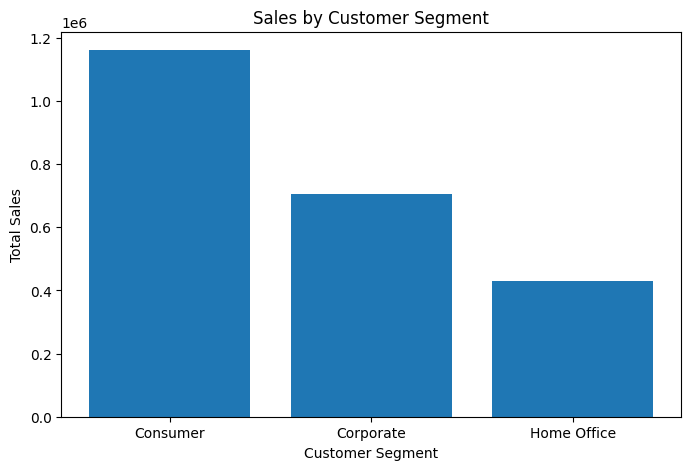

In [35]:
plt.figure(figsize=(8,5))

plt.bar(segment_sales.index, segment_sales.values)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.show()

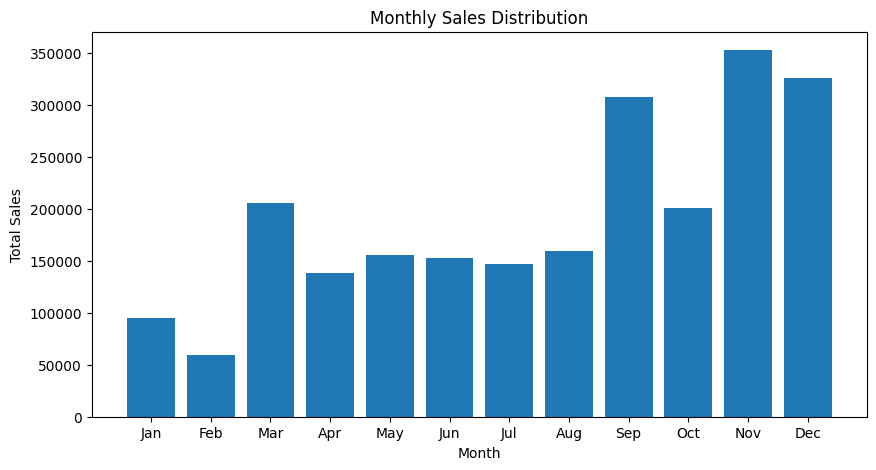

In [36]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales = monthly_sales.reindex(range(1, 13), fill_value=0)

month_names = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

plt.figure(figsize=(10,5))

bars = plt.bar(month_names, monthly_sales)

plt.title("Monthly Sales Distribution")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

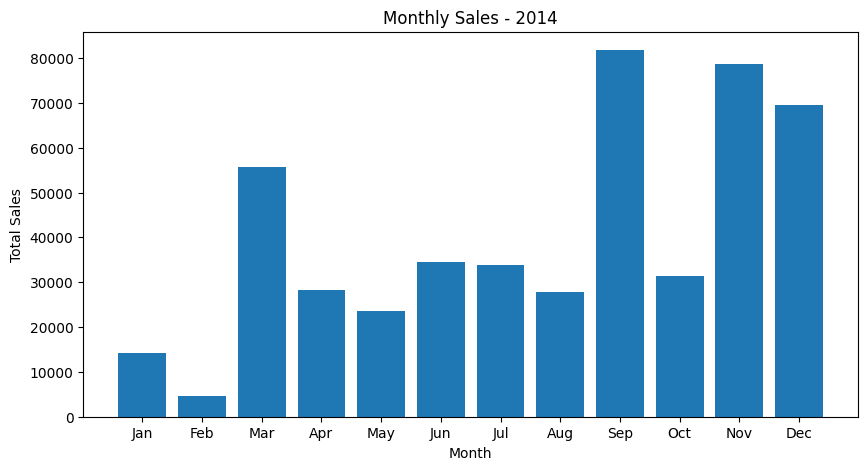

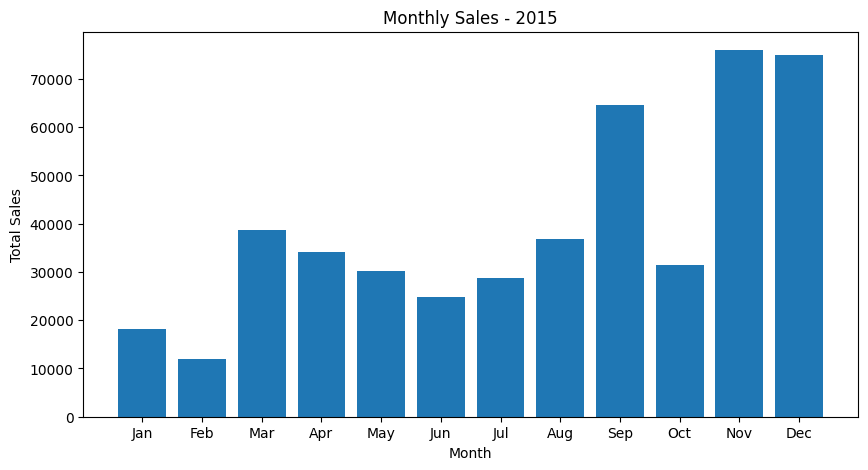

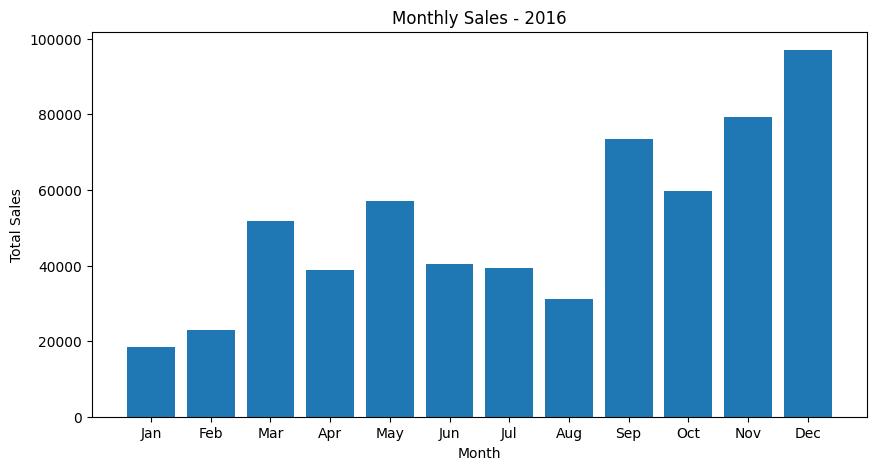

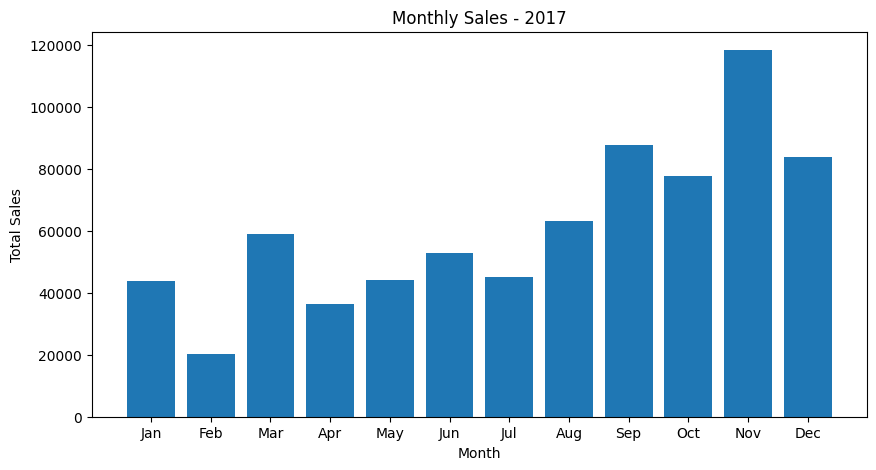

In [37]:
for year in sorted(df['Year'].unique()):

    data = (
        df[df['Year'] == year]
        .groupby('Month')['Sales']
        .sum()
    )

    data = data.reindex(range(1, 13), fill_value=0)

    plt.figure(figsize=(10,5))

    bars = plt.bar(month_names, data)

    plt.title(f"Monthly Sales - {year}")
    plt.xlabel("Month")
    plt.ylabel("Total Sales")

    plt.show()

In [39]:
shipping_counts = df['Ship Mode'].value_counts()

print(shipping_counts)

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64


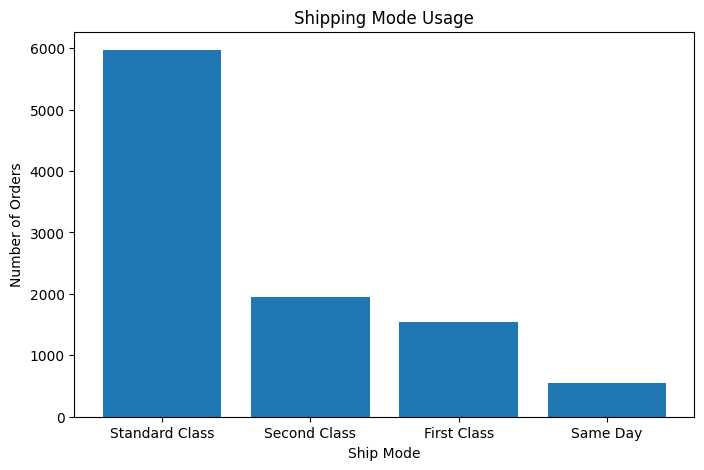

In [40]:
plt.figure(figsize=(8,5))

plt.bar(shipping_counts.index, shipping_counts.values)

plt.title("Shipping Mode Usage")
plt.xlabel("Ship Mode")
plt.ylabel("Number of Orders")

plt.show()

In [41]:
order_profit = df.groupby('Order ID')['Profit'].sum()

average_profit_per_order = order_profit.mean()

print(f"Average Profit per Order: ${average_profit_per_order:,.2f}")

Average Profit per Order: $57.18


In [42]:
state_performance = df.groupby('State')[['Sales', 'Profit']].sum()

underperforming_states = state_performance.sort_values(
    'Profit'
).head(10)

print(underperforming_states)

                      Sales      Profit
State                                  
Texas           170188.0458 -25729.3563
Ohio             78258.1360 -16971.3766
Pennsylvania    116511.9140 -15559.9603
Illinois         80166.1010 -12607.8870
North Carolina   55603.1640  -7490.9122
Colorado         32108.1180  -6527.8579
Tennessee        30661.8730  -5341.6936
Arizona          35282.0010  -3427.9246
Florida          89473.7080  -3399.3017
Oregon           17431.1500  -1190.4705


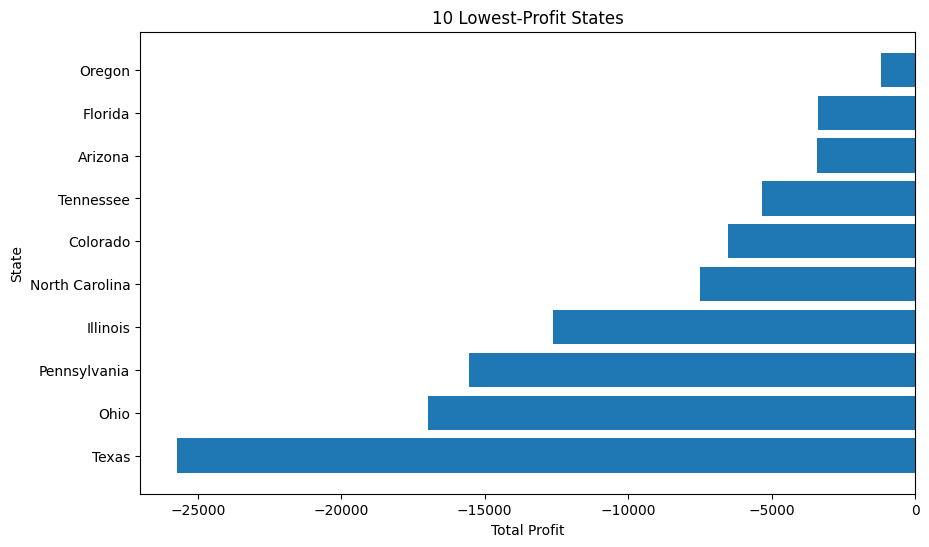

In [43]:
plt.figure(figsize=(10,6))

plt.barh(
    underperforming_states.index,
    underperforming_states['Profit']
)

plt.title("10 Lowest-Profit States")
plt.xlabel("Total Profit")
plt.ylabel("State")

plt.show()

In [44]:
city_performance = df.groupby('City')[['Sales', 'Profit']].sum()

underperforming_cities = city_performance.sort_values(
    'Profit'
).head(10)

print(underperforming_cities)

                    Sales      Profit
City                                 
Philadelphia  109077.0130 -13837.7674
Houston        64504.7604 -10153.5485
San Antonio    21843.5280  -7299.0502
Lancaster       9891.4640  -7239.0684
Chicago        48539.5410  -6654.5688
Burlington     21668.0820  -3622.8772
Dallas         20131.9322  -2846.5257
Phoenix        11000.2570  -2790.8832
Aurora         11656.4780  -2691.7386
Jacksonville   44713.1830  -2323.8350


In [45]:
quantity_profit = df.groupby('Quantity')['Profit'].sum()

print(quantity_profit)

Quantity
1      7440.4801
2     38448.4088
3     57015.5250
4     44223.3908
5     49516.5945
6     10325.4678
7     34286.9730
8     10856.7960
9     17687.8908
10     2044.1570
11     4293.3671
12     1185.0660
13     6348.9010
14     2724.0038
Name: Profit, dtype: float64


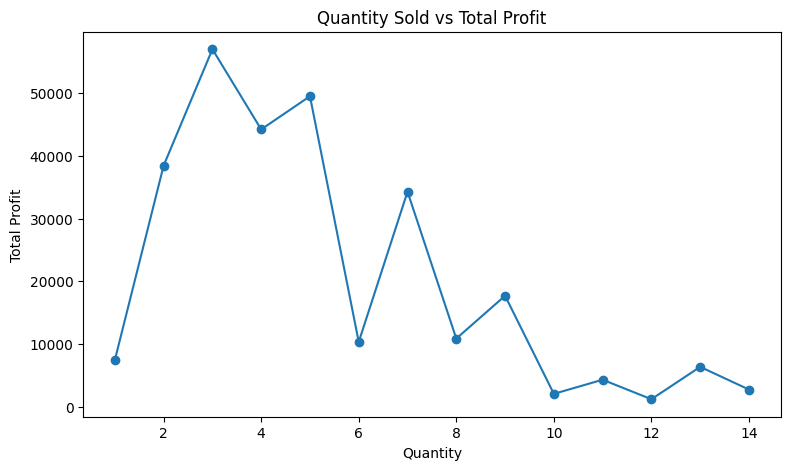

In [46]:
plt.figure(figsize=(9,5))

plt.plot(
    quantity_profit.index,
    quantity_profit.values,
    marker='o'
)

plt.title("Quantity Sold vs Total Profit")
plt.xlabel("Quantity")
plt.ylabel("Total Profit")

plt.show()

In [47]:
quantity_correlation = df['Quantity'].corr(df['Profit'])

print("Quantity-Profit Correlation:", quantity_correlation)

Quantity-Profit Correlation: 0.06625318912428488


In [48]:
top_products = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


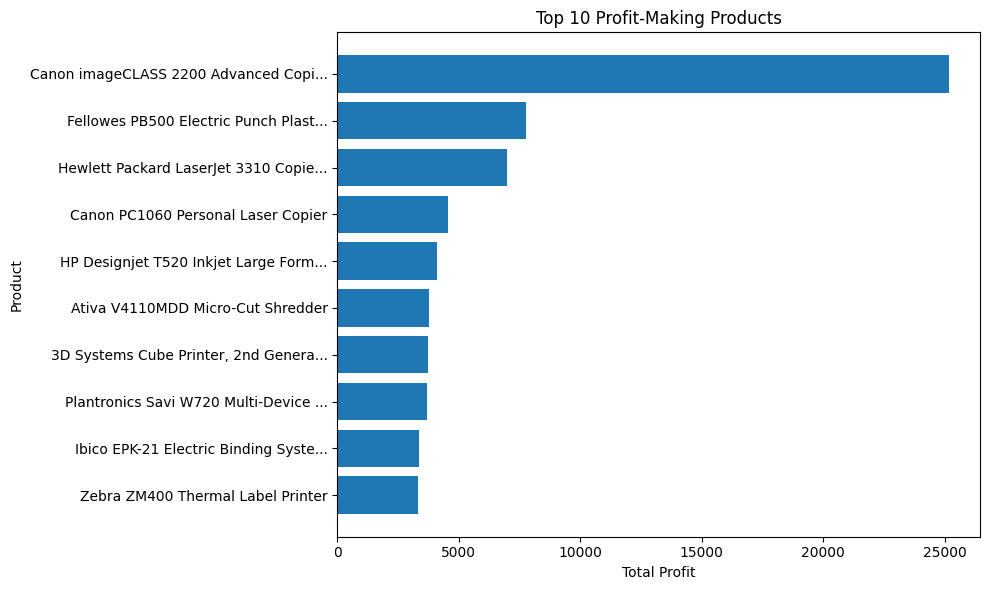

In [49]:
top_products = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

short_names = [
    name[:35] + "..." if len(name) > 35 else name
    for name in top_products.index
]

plt.figure(figsize=(10,6))

plt.barh(short_names[::-1], top_products.values[::-1])

plt.title("Top 10 Profit-Making Products")
plt.xlabel("Total Profit")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

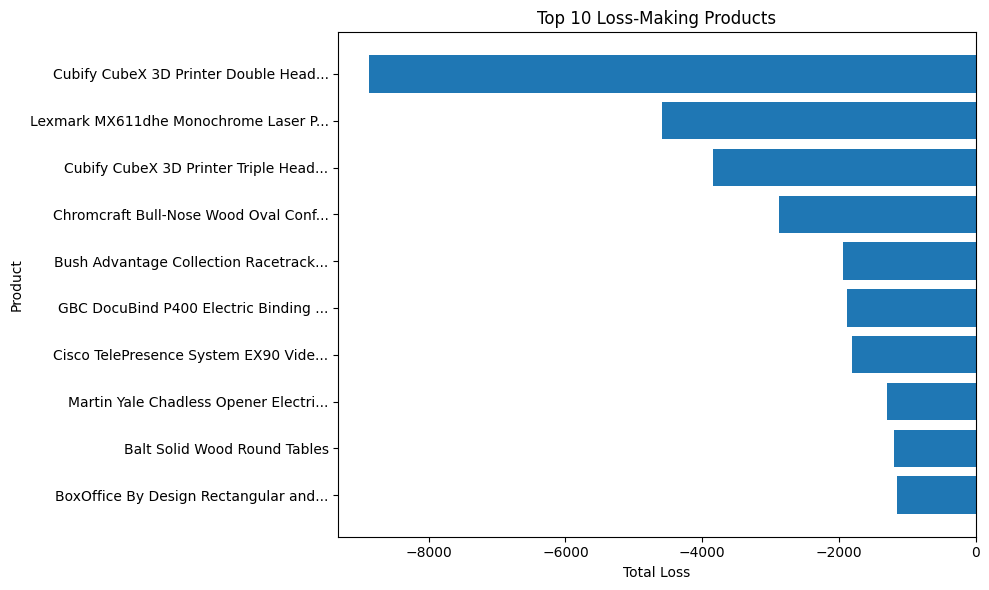

In [51]:
loss_products = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

short_loss_names = [
    name[:35] + "..." if len(name) > 35 else name
    for name in loss_products.index
]

plt.figure(figsize=(10,6))

plt.barh(short_loss_names[::-1], loss_products.values[::-1])

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Total Loss")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

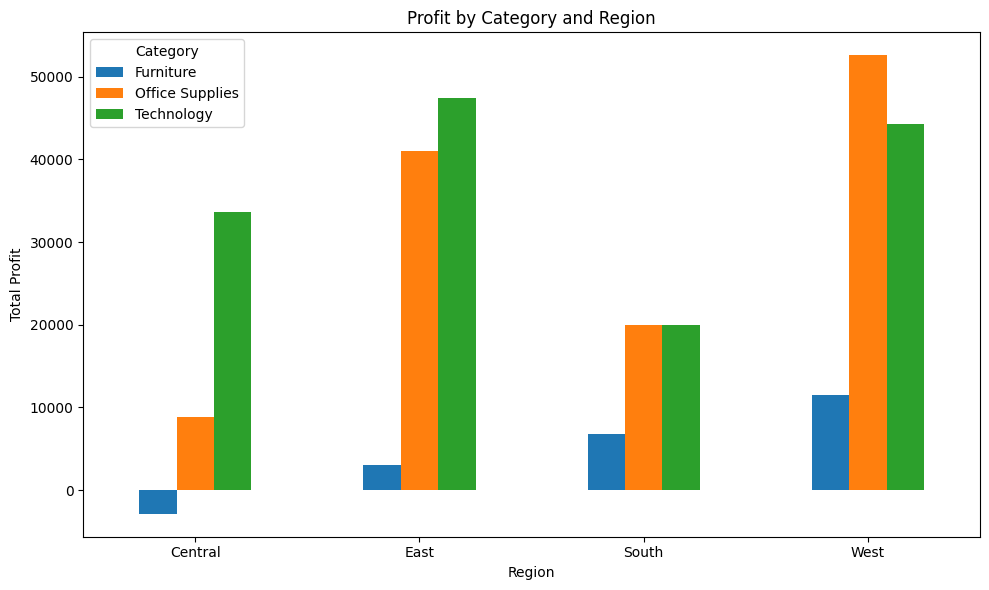

In [52]:
category_region_profit = df.pivot_table(
    values='Profit',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

category_region_profit.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Profit by Category and Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)
plt.legend(title="Category")

plt.tight_layout()
plt.show()

In [53]:
# Make sure dates are in the correct format
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

# Aggregate data by Month and Category
agg_df = df.groupby(['Month', 'Category']).agg({
    'Profit': 'sum',
    'Sales': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean'
}).reset_index()

agg_df.head()

,Month,Category,Profit,Sales,Quantity,Discount
0,1,Furniture,-1944.2130,31569.2416,345,0.157037
1,1,Office Supplies,6243.7654,33233.8310,859,0.144493
2,1,Technology,4834.8937,30121.7630,271,0.158904
3,2,Furniture,693.5796,15765.9204,208,0.178889
4,2,Office Supplies,4274.0190,20641.9130,658,0.148023


In [55]:
agg_df['Sales_x_Quantity'] = (
    agg_df['Sales'] * agg_df['Quantity']
)

agg_df['Discount_x_Quantity'] = (
    agg_df['Discount'] * agg_df['Quantity']
)

In [56]:
shift = (
    1 - agg_df['Profit'].min()
    if agg_df['Profit'].min() <= 0
    else 0
)

agg_df['Profit_Log'] = np.log1p(
    agg_df['Profit'] + shift
)

In [57]:
X = agg_df[
    [
        'Sales',
        'Quantity',
        'Discount',
        'Sales_x_Quantity',
        'Discount_x_Quantity'
    ]
]

# Convert Category into numerical dummy variables
category_dummies = pd.get_dummies(
    agg_df['Category'],
    drop_first=True
)

X = pd.concat(
    [X, category_dummies],
    axis=1
)

y = agg_df['Profit_Log']

print(X.head())

        Sales  Quantity  Discount  Sales_x_Quantity  Discount_x_Quantity  \
0  31569.2416       345  0.157037      1.089139e+07            54.177778   
1  33233.8310       859  0.144493      2.854786e+07           124.119824   
2  30121.7630       271  0.158904      8.162998e+06            43.063014   
3  15765.9204       208  0.178889      3.279311e+06            37.208889   
4  20641.9130       658  0.148023      1.358238e+07            97.398870   

   Office Supplies  Technology  
0            False       False  
1             True       False  
2            False        True  
3            False       False  
4             True       False  


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 28
Testing rows: 8


In [59]:
from sklearn.linear_model import LinearRegression, RANSACRegressor

ransac = RANSACRegressor(
    estimator=LinearRegression(),
    min_samples=0.5,
    residual_threshold=0.5,
    random_state=42
)

ransac.fit(X_train, y_train)

RANSACRegressor(estimator=LinearRegression(), min_samples=0.5, random_state=42,
                residual_threshold=0.5)

In [61]:
y_pred_log = ransac.predict(X_test)

# Convert predictions back to original profit scale
y_pred = np.expm1(y_pred_log) - shift

# Get original actual profit values
y_test_actual = agg_df.loc[y_test.index, 'Profit']

In [62]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(
    y_test_actual,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred
    )
)

# Log-scale error
y_test_log = np.log1p(
    y_test_actual + shift
)

y_pred_log_safe = np.log1p(
    y_pred + shift
)

log_perc_error = np.mean(
    np.abs(
        y_pred_log_safe - y_test_log
    )
) * 100

print(f"Robust Linear Regression R²: {r2:.3f}")
print(f"RMSE: ${rmse:,.2f}")
print(
    f"Average prediction error (log scale): "
    f"{log_perc_error:.1f}%"
)

Robust Linear Regression R²: 0.503
RMSE: $4,483.66
Average prediction error (log scale): 32.2%


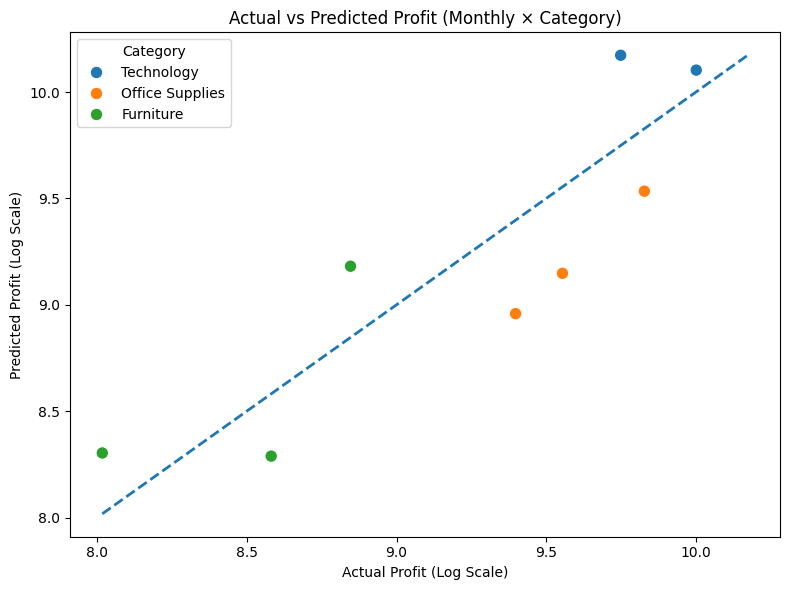

In [63]:
plt.figure(figsize=(8,6))

categories_test = agg_df.loc[
    y_test.index,
    'Category'
]

sns.scatterplot(
    x=y_test_log,
    y=y_pred_log_safe,
    hue=categories_test,
    s=80
)

# Perfect prediction line
min_value = min(
    y_test_log.min(),
    y_pred_log_safe.min()
)

max_value = max(
    y_test_log.max(),
    y_pred_log_safe.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    '--',
    linewidth=2
)

plt.xlabel("Actual Profit (Log Scale)")
plt.ylabel("Predicted Profit (Log Scale)")

plt.title(
    "Actual vs Predicted Profit "
    "(Monthly × Category)"
)

plt.legend(title="Category")

plt.tight_layout()
plt.show()

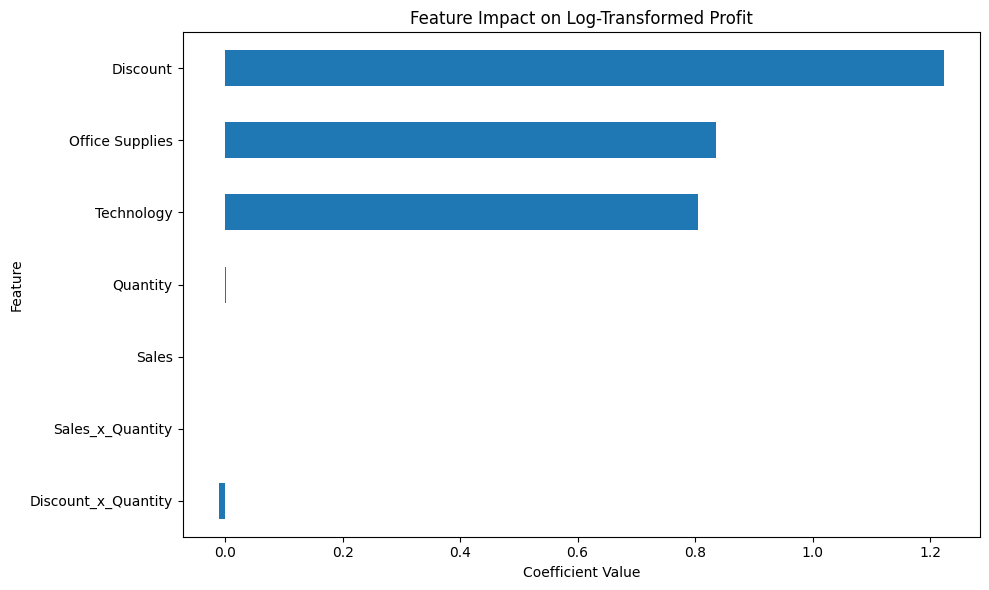

In [64]:
coef = pd.Series(
    ransac.estimator_.coef_,
    index=X.columns
)

coef.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Impact on Log-Transformed Profit")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()